/usr/local/python/3.10.20/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


带通滤波完成：8-30Hz
平均重参考完成
Creating RawArray with float64 data, n_channels=18, n_times=672528
    Range : 0 ... 672527 =      0.000 ...  2690.108 secs
Ready.


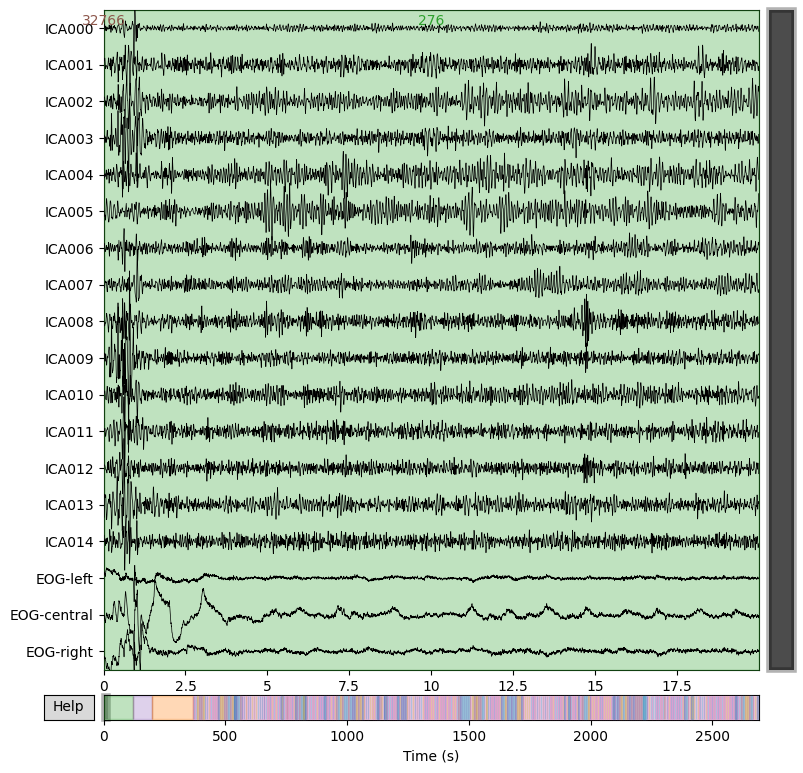

RuntimeError: Did not find any digitization points of kind 3 (FIFFV_POINT_EEG) in the info.

In [ ]:
import mne
import matplotlib.pyplot as pl

file_path = "datasets/bciciv2a_gdf/A01T.gdf"
raw = mne.io.read_raw_gdf("datasets/bciciv2a_gdf/A01T.gdf",
                          eog=["EOG-left", "EOG-central", "EOG-right"],
                          preload=True,
                          verbose=False)


#1.1
#print("raw info")
#print(raw.info)

#print("data shape")
#print(raw.get_data().shape)

#print("raw annotations")
#print(raw.annotations)

#events, event_id = mne.events_from_annotations(raw)
#print(events)

#raw.plot()
#pl.show()


# 1.2
raw.set_montage(mne.channels.make_standard_montage("standard_1020"), on_missing="ignore")
raw.filter(l_freq=8, h_freq=30, fir_design='firwin', verbose=False) # FIR 时域卷积滤波（有限长的“加权滑动平均”） 零相位正反滤波，不漂移、不延时；FFT容易有窗口截断伪迹，波形容易畸变、边缘失真
print("带通滤波完成：8-30Hz")
mne.set_eeg_reference(raw, 'average', verbose=False)
print("平均重参考完成")
ica = mne.preprocessing.ICA(
    n_components=15,      # 提取15个独立成分（根据数据调整，一般10-20）
    random_state=42,     # 固定随机种子，保证结果可复现
    max_iter="auto",     # 自动迭代次数
    verbose=False
)
ica.fit(raw, verbose=False)
# 方法1：自动检测眼电（EOG）伪迹成分
eog_indices, eog_scores = ica.find_bads_eog(raw, verbose=False)
#print(f"自动识别的眼电伪迹成分：{eog_indices}")

# 方法2：手动查看ICA成分，确认伪迹（可视化，关闭窗口继续运行）
ica.plot_sources(raw)  # 查看成分波形

# 4.4 剔除伪迹成分，还原干净信号
ica.exclude = eog_indices  # 设置需要剔除的成分
raw_clean = ica.apply(raw, verbose=False)  # 应用ICA去噪
print("ICA去除眼电伪迹完成")
# 5.1 从原始数据中提取事件（事件标记）
events, event_id = mne.events_from_annotations(raw, verbose=False)
print(f"📊 提取到 {len(events)} 个事件，事件ID：{event_id}")

# 5.2 定义Epoch时间窗口
tmin = -0.5  # 事件发生前 0.5 秒（基线）
tmax = 2.0   # 事件发生后 2 秒
baseline = (None, 0)  # 基线校正：用事件前的信号做基线

# 5.3 切割连续数据为试次（Epochs）
epochs = mne.Epochs(
    raw_clean,        # 预处理后的干净数据
    events=events,    # 事件标记
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=baseline,
    preload=True,
    verbose=False
)
print("Epochs试次切割完成")

epochs.plot(
    n_epochs=15,      # 一次显示多少个trials
    n_channels=22,    # 一次显示多少个通道
    scalings="auto",  # 自动缩放幅值
    show=True
)
# 画叠加平均 ERP 曲线
epochs.average().plot()
# 不依赖电极定位，只画时序，不画头皮拓扑
epochs.plot_image()